In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
import datetime as dt
import math

In [3]:
headr = "Tc:Ta:TcRise:TaRise:cat:an:offst:datime:IR:UV:chi2:nAvg:nTrig".split(':')
A = np.loadtxt("100micro.txt",delimiter=',',dtype=[(i, np.float32) for i in headr])

In [4]:
y = (A['Tc']-A['Ta'])/np.log(A['an']/A['cat'])
x = np.array([dt.datetime.fromtimestamp(float(i-(126144000+2208988800))) for i in A['datime']])

(np.float64(19193.0), np.float64(19194.5))

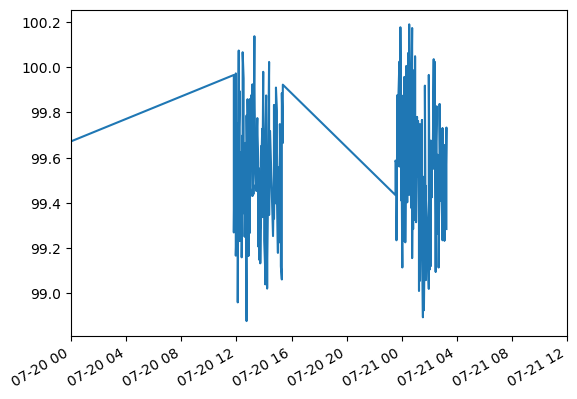

In [5]:
plt.plot(x,y)
plt.gcf().autofmt_xdate()
plt.xlim(dt.datetime(2022,7,20,0,0),dt.datetime(2022,7,21,12,0))

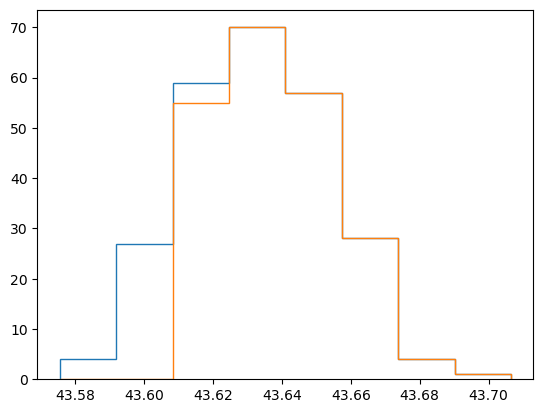

In [12]:
ts,te = dt.datetime(2022,7,20,0,0),dt.datetime(2022,7,21,12,0)
n_hrs = math.ceil((te-ts).total_seconds()/3600)

cut = A['offst']>43.612  #An example cut, you end up w/ a binary mask
plt.hist(A['offst'],bins=8,range=(min(A['offst']),max(A['offst'])),histtype='step')
plt.hist(A[cut]['offst'],bins=8,range=(min(A['offst']),max(A['offst'])),histtype='step');

In [7]:
be = [ts+dt.timedelta(hours=i) for i in range(n_hrs+1)]
B = np.zeros((len(A),n_hrs),dtype=np.bool)
# This determines which entry belongs to which bin (in time)
for i in range(n_hrs):
    B[:,i] = np.logical_and(x>be[i],x<be[i+1])

C:\Users\bung\anaconda3\envs\pydan\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\bung\anaconda3\envs\pydan\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\bung\anaconda3\envs\pydan\Lib\site-packages\numpy\_core\_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\bung\anaconda3\envs\pydan\Lib\site-packages\numpy\_core\_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\bung\anaconda3\envs\pydan\Lib\site-packages\numpy\_core\_methods.py:210: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


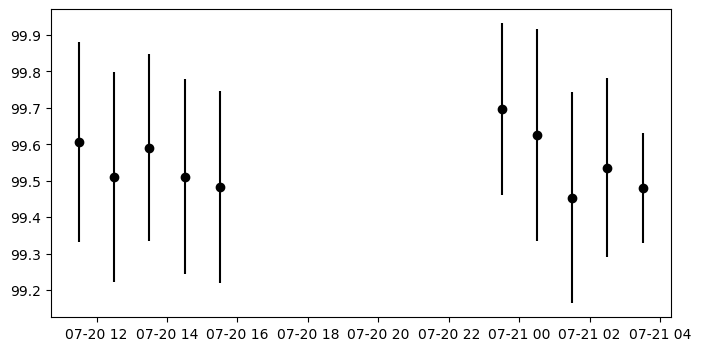

In [8]:
plt.figure(figsize=(8,4))
for i in range(n_hrs):
    yb = np.mean(y[B[:,i]])
    y_std = np.std(y[B[:,i]])
    xb = be[i]+ (be[i+1]-be[i])/2.
    plt.plot(xb,yb,'ko')
    plt.errorbar(x=xb,y=yb,yerr=y_std,fmt='k')